In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

## Wstęp

In [3]:
df = pd.read_csv('../data/train.csv')

In [4]:
df.shape

(593994, 13)

In [5]:
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [6]:
del df['id']  # Usuwamy kolumnę 'id', która nie jest potrzebna do analizy

## Jakość Danych

In [7]:
# Nie ma nulli 
df.isnull().sum()

annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [8]:
# Nie ma zduplikowanych wierszy
df.duplicated().sum()

0

## Analiza Jednowymiarowa

In [14]:
df['loan_to_income'] = df['loan_amount'] / df['annual_income']

In [15]:
cat_col = df.select_dtypes(include='object').columns.tolist()
num_col = df.select_dtypes(include='number').columns.tolist()

In [16]:
# ~80% jest spłaconych kredytów, jest niezrównowazenie między spłaconymi i nie
df['loan_paid_back'].value_counts(normalize=True)

loan_paid_back
1.0    0.79882
0.0    0.20118
Name: proportion, dtype: float64

In [ ]:
#Bardzo niezrównoważona kateogoria "other"
df['gender'].value_counts(normalize=True)

gender
Female    0.515451
Male      0.478273
Other     0.006276
Name: proportion, dtype: float64

In [ ]:
# DODAĆ OPIS DANYCH
desc = df[num_col].describe()
# DODAJEMY MEDIANĘ I MODĘ, ponieważ są bardziej odporne na wartości odstające niż średnia
desc.loc['median'] = df[num_col].median()
desc.loc['mode'] = df[num_col].mode().iloc[0]
desc = desc.drop('count')

desc

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back,loan_to_income
mean,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820,0.427574
std,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883,0.366041
min,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000,0.002491
25%,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000,0.194734
50%,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000,0.322538
75%,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000,0.536990
max,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000,5.461143
median,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000,0.322538
mode,51351.710000,0.090000,678.000000,12892.250000,12.310000,1.000000,1.000000


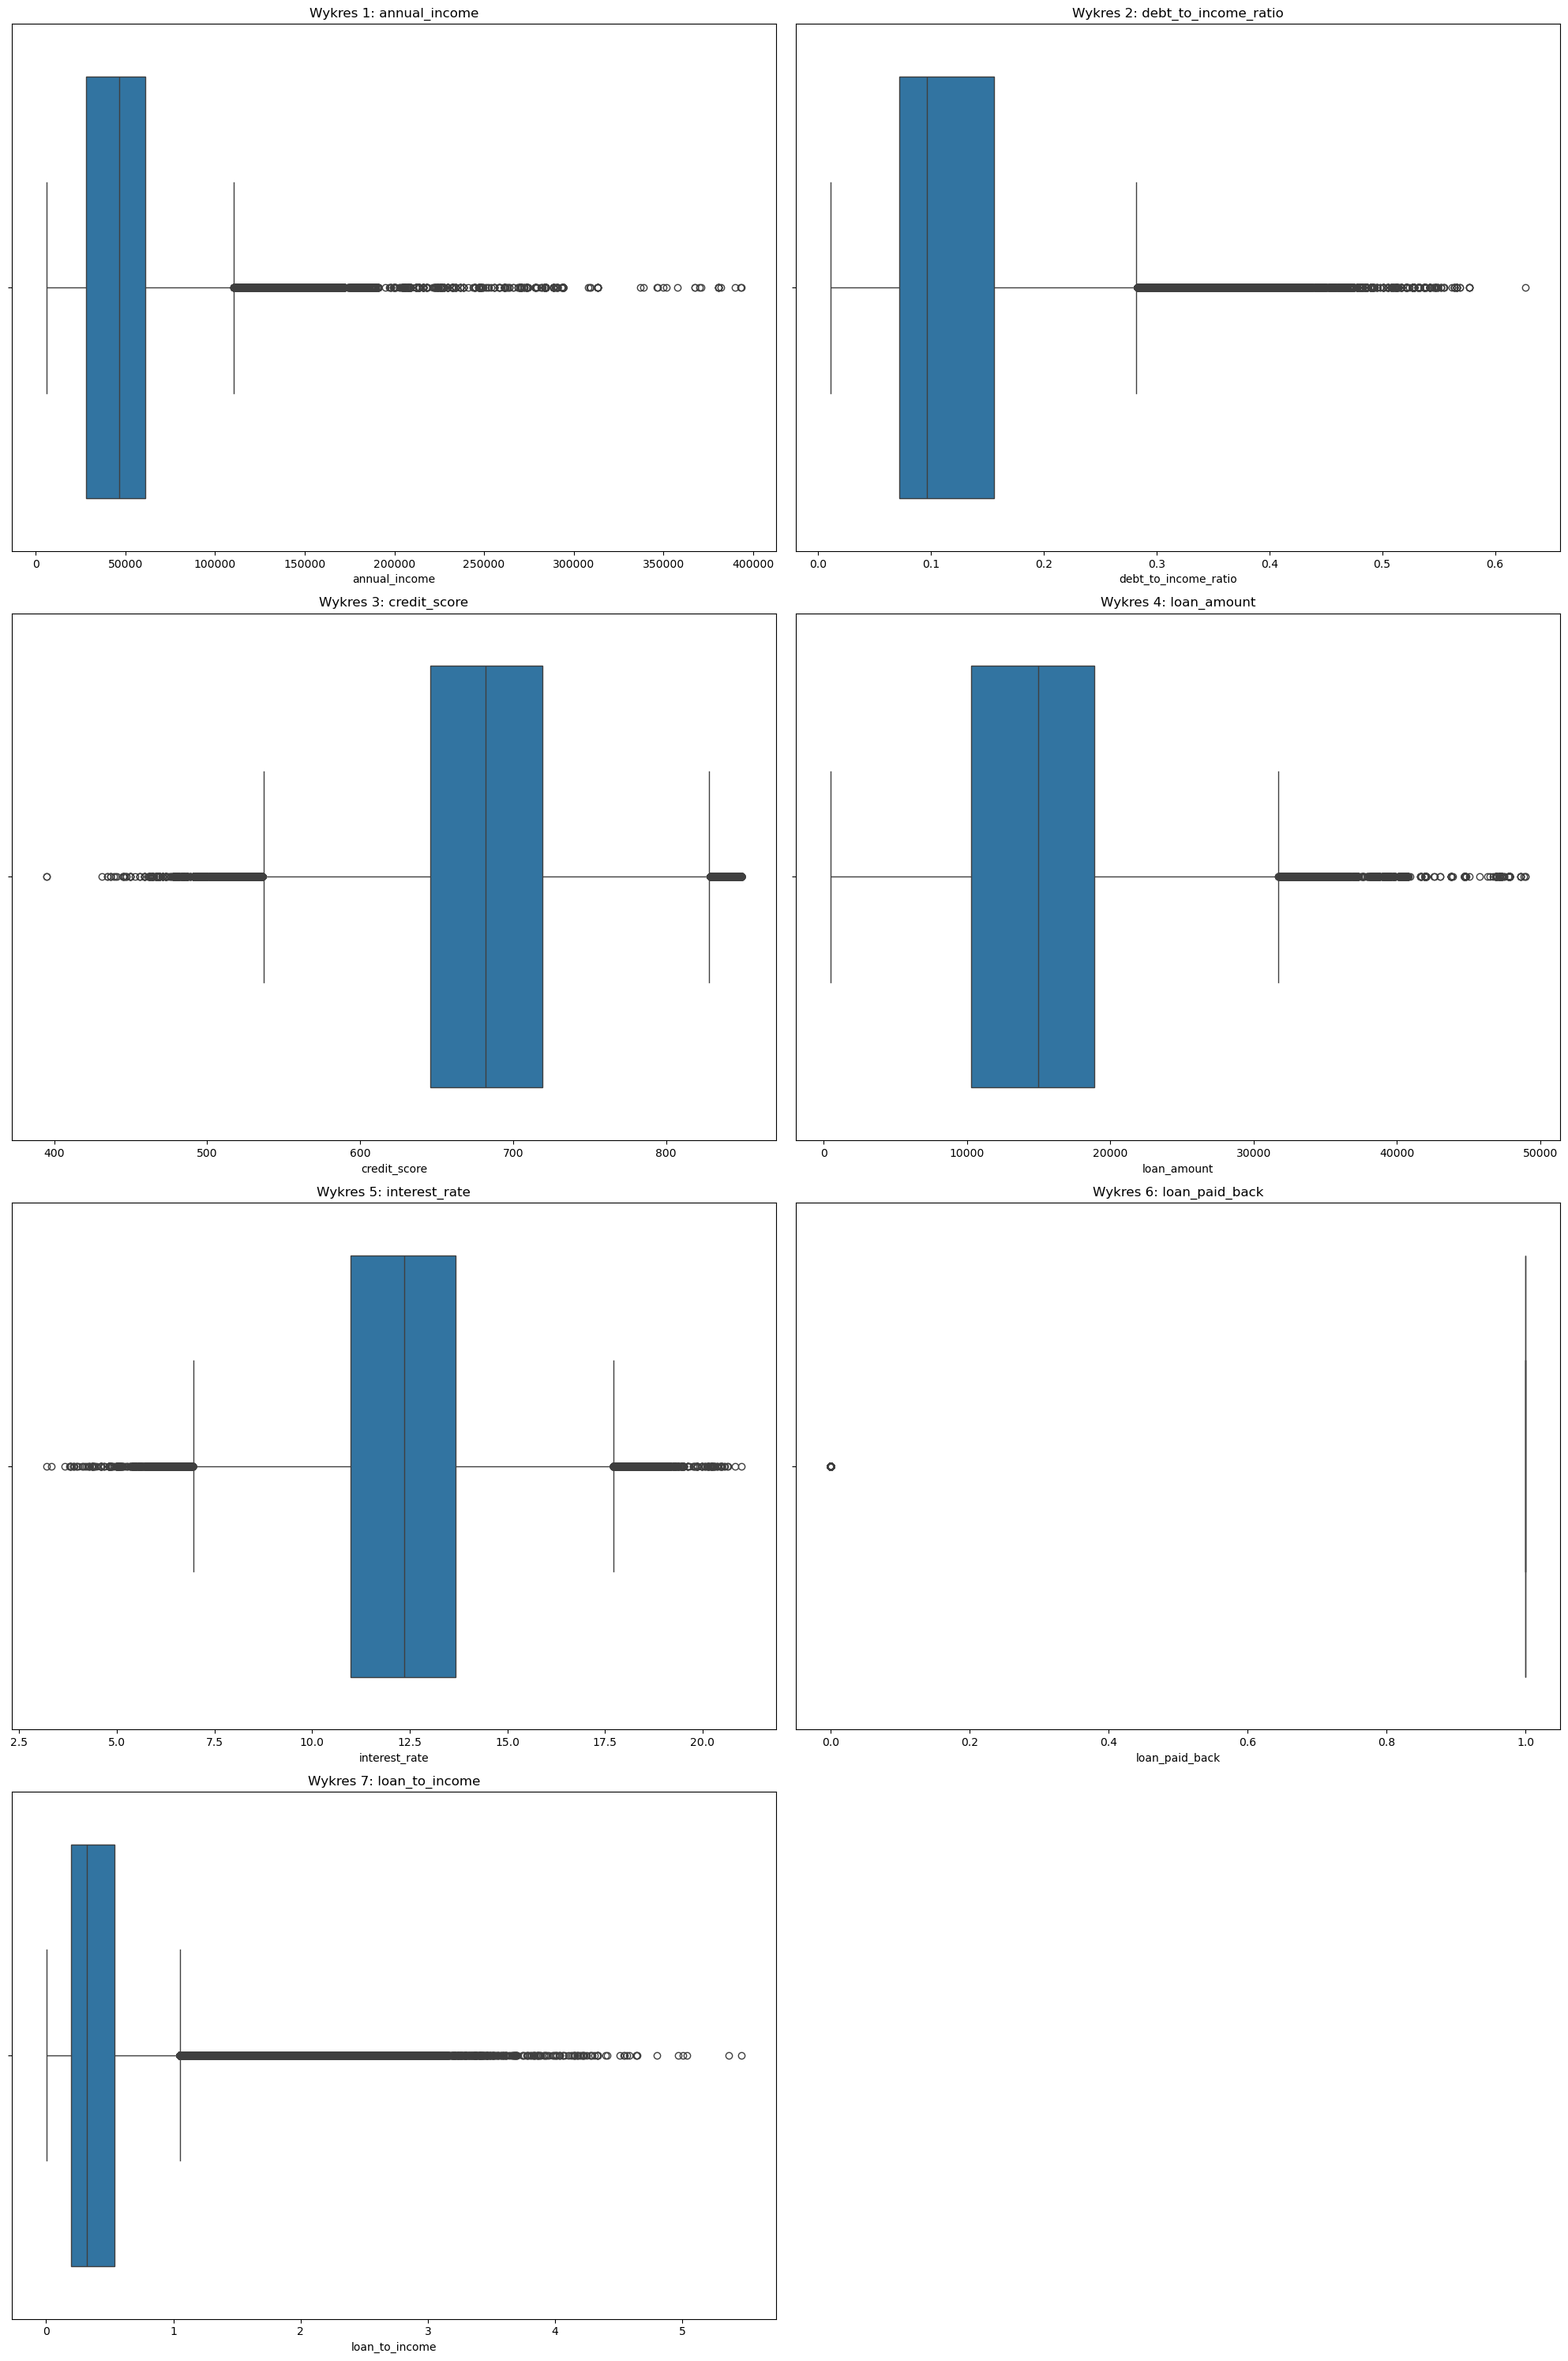

In [ ]:
# DODAĆ OPIS WYKRESóW
plt.figure(figsize=(20, 30))

for i, c in enumerate(num_col, 1):
    plt.subplot(4, 2, i)  
    sns.boxplot(x=df[c])
    plt.title(f'Wykres {i}: {c}')

plt.tight_layout()
plt.show()

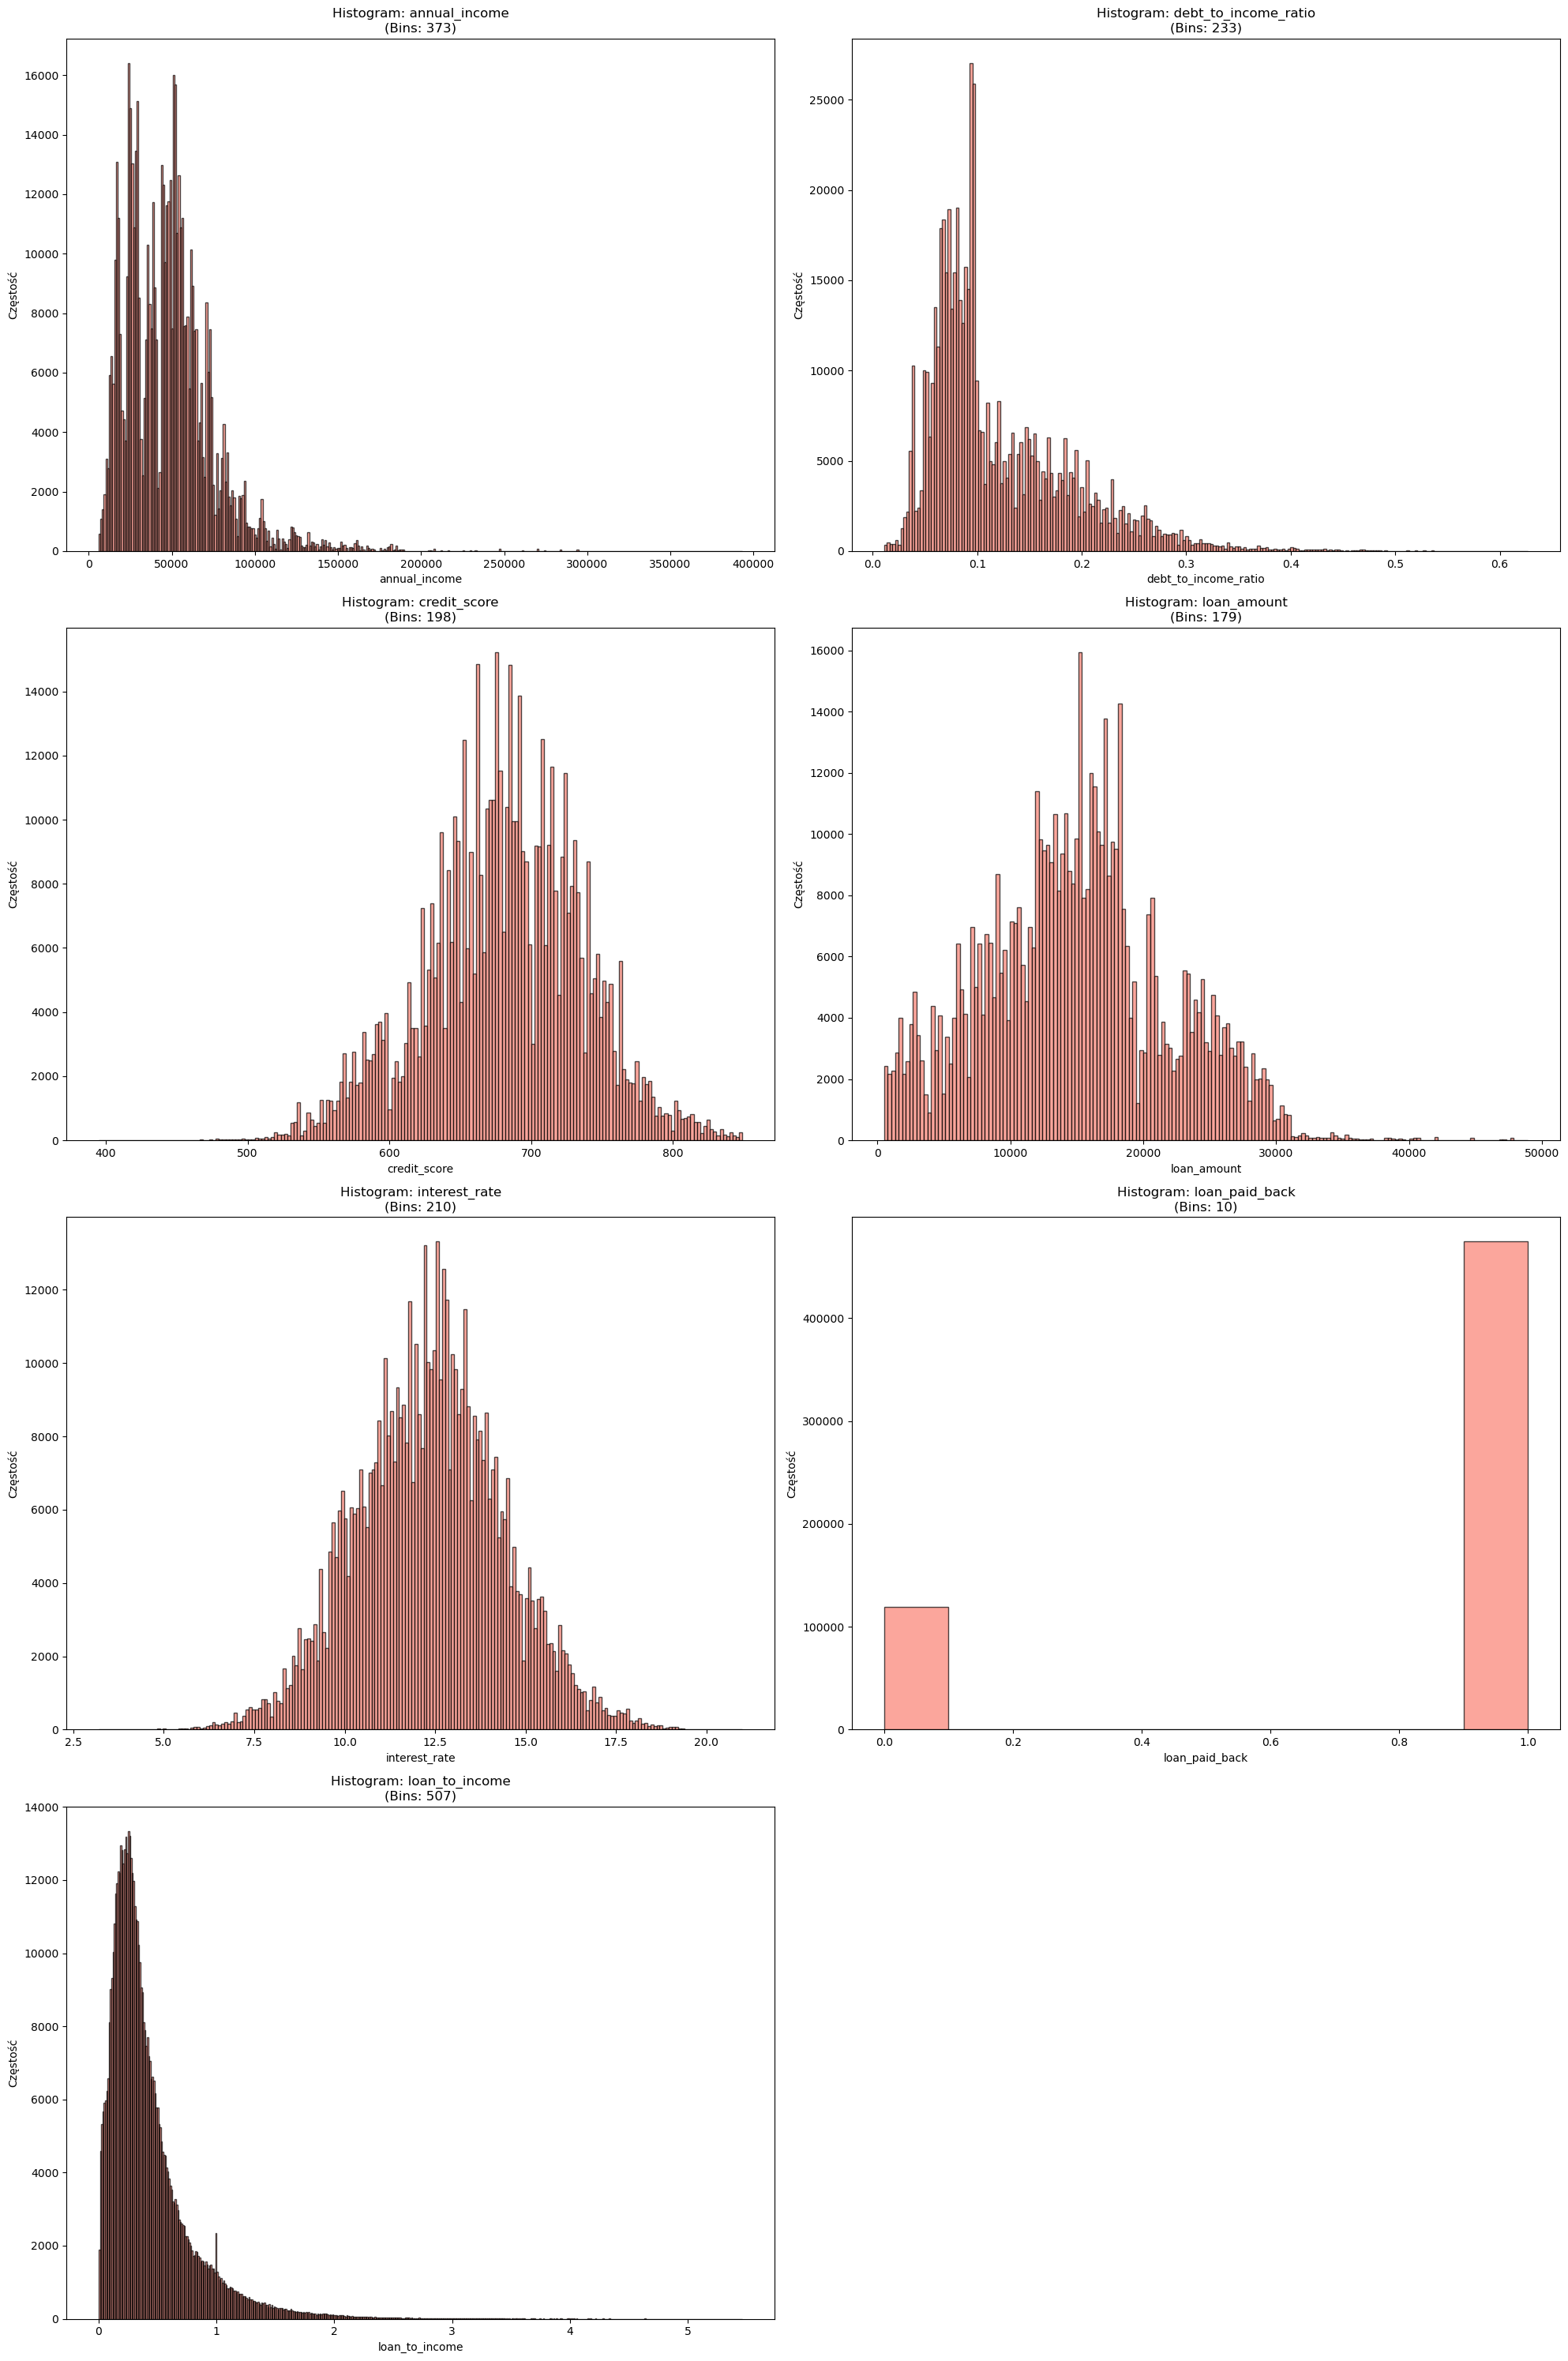

In [32]:
import numpy as np

plt.figure(figsize=(20, 30)) # Duże płótno dla 7 histogramów

for i, c in enumerate(num_col, 1):
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1

    h = 2.64 * IQR * pow(len(df[c]), (-1/3))

    if h > 0:
        num_bins = int((df[c].max() - df[c].min()) / h)
    else:
        num_bins = 10

    plt.subplot(4, 2, i)
    plt.hist(df[c], bins=num_bins, color='salmon', edgecolor='black', alpha=0.7)
    
    plt.title(f'Histogram: {c}\n(Bins: {num_bins})', fontsize=12)
    plt.xlabel(c)
    plt.ylabel('Częstość')

plt.tight_layout()
plt.show()

## Analiza Relacji

In [34]:
# dość silna korelacja interest_rate i credit_score
correlation = df[num_col].corr()
correlation

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back,loan_to_income
annual_income,1.000000,0.000553,0.001509,-0.003407,-0.002507,0.006326,-0.572122
debt_to_income_ratio,0.000553,1.000000,-0.061617,-0.008236,0.030316,-0.335680,-0.002835
credit_score,0.001509,-0.061617,1.000000,-0.005761,-0.538335,0.234560,-0.007187
loan_amount,-0.003407,-0.008236,-0.005761,1.000000,-0.001174,-0.003762,0.546287
interest_rate,-0.002507,0.030316,-0.538335,-0.001174,1.000000,-0.131184,0.004983
loan_paid_back,0.006326,-0.335680,0.234560,-0.003762,-0.131184,1.000000,-0.005611
loan_to_income,-0.572122,-0.002835,-0.007187,0.546287,0.004983,-0.005611,1.000000


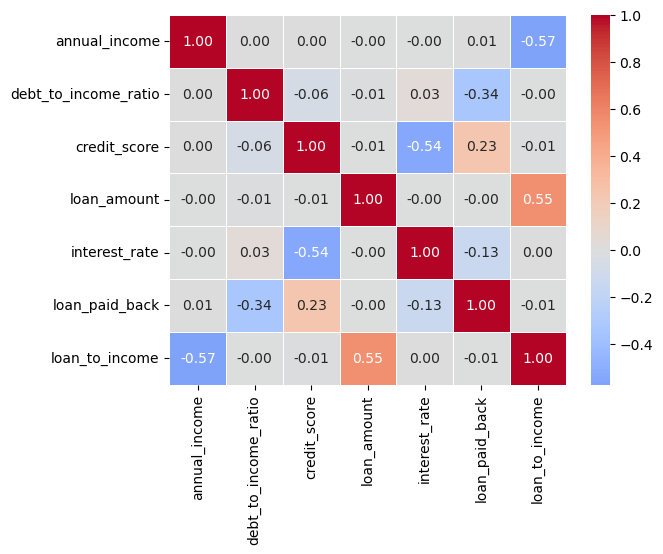

In [ ]:
# OPISAĆ KORELACJĘ, SZCZEGLNIE dla loan_paid_back
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.show()

## Outliery

## Feature engineering i onehot encoding

In [46]:
df_ex = df.copy()
df_ex['grade_letter'] = df['grade_subgrade'].str[0]
df_ex['subgrade_num'] = df['grade_subgrade'].str[1:].astype(int)

In [47]:
grade_map = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6}
df_ex['grade_letter_rank'] = df_ex['grade_letter'].map(grade_map)

In [ ]:
del df_ex['grade_subgrade']
del df_ex['grade_letter']

In [48]:
education_ranking = {"PhD": 5, "Master's": 4, "Bachelor's": 3, "High School": 2, "Other": 1}
df_ex['education_rank'] = df_ex['education_level'].map(education_ranking)

In [53]:
del df_ex['education_level']

In [49]:
df_ex = pd.get_dummies(df_ex, columns=['gender', 'marital_status', 'employment_status', 'loan_purpose'], drop_first=True)

In [50]:
def apply_feature_engineering(df):

    df['disposable_income'] = df['annual_income'] * (1 - df['debt_to_income_ratio'])
    df['interest_to_income_ratio'] = (df['loan_amount'] * df['interest_rate']) / df['annual_income']
    df['risk_score_ratio'] = df['interest_rate'] / (df['credit_score'] + 1)
    df['dti_squared'] = df['debt_to_income_ratio'] ** 2
    df['loan_per_credit_point'] = df['loan_amount'] / df['credit_score']
    
    return df

df_ex = apply_feature_engineering(df_ex)

In [58]:
df_ex.columns

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'loan_paid_back', 'loan_to_income', 'subgrade_num',
       'grade_letter_rank', 'education_rank', 'gender_Male', 'gender_Other',
       'marital_status_Married', 'marital_status_Single',
       'marital_status_Widowed', 'employment_status_Retired',
       'employment_status_Self-employed', 'employment_status_Student',
       'employment_status_Unemployed', 'loan_purpose_Car',
       'loan_purpose_Debt consolidation', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Medical', 'loan_purpose_Other',
       'loan_purpose_Vacation', 'disposable_income',
       'interest_to_income_ratio', 'risk_score_ratio', 'dti_squared',
       'loan_per_credit_point'],
      dtype='object')

## Modelowanie

In [59]:
X = df_ex.drop(['loan_paid_back'], axis=1)
y = df_ex['loan_paid_back']

In [60]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score

X = df_ex.drop(['loan_paid_back'], axis=1)
y = df_ex['loan_paid_back']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models = []

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 63,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'feature_fraction': 0.8,
    'random_state': 42,
    'verbosity': -1
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

 
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[train_data, val_data],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=100)
        ]
    )
    oof_preds[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    models.append(model)

full_auc = roc_auc_score(y, oof_preds)
print(f"\nOverall OOF AUC: {full_auc:.4f}")

Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.916915	valid's auc: 0.917272
[200]	train's auc: 0.921142	valid's auc: 0.919369
[300]	train's auc: 0.924767	valid's auc: 0.92082
[400]	train's auc: 0.927265	valid's auc: 0.921331
[500]	train's auc: 0.93001	valid's auc: 0.922062
[600]	train's auc: 0.932439	valid's auc: 0.922593
[700]	train's auc: 0.934231	valid's auc: 0.922779
[800]	train's auc: 0.936059	valid's auc: 0.922916
Early stopping, best iteration is:
[822]	train's auc: 0.936364	valid's auc: 0.92294
Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.917031	valid's auc: 0.916417
[200]	train's auc: 0.920861	valid's auc: 0.918275
[300]	train's auc: 0.924531	valid's auc: 0.92008
[400]	train's auc: 0.927487	valid's auc: 0.92126
[500]	train's auc: 0.930016	valid's auc: 0.921901
[600]	train's auc: 0.932125	valid's auc: 0.922371
Early stopping, best iteration is:
[634]	train's auc: 0.932726	valid's auc: 0.922449
Training unti

In [ ]:
model.save_model('../models/loan_repayment_model_26.03_Lightgbm.json')

In [64]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score

X = df_ex.drop(['loan_paid_back'], axis=1)
y = df_ex['loan_paid_back']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
    dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)
    
    params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'learning_rate': 0.014366,
    'max_depth': 10,
    'min_child_weight': 10,
    'subsample': 0.8629,
    'colsample_bytree': 0.5000,
    'gamma': 0.0011,
    'lambda': 1.45e-08,
    'alpha': 1.36e-08,
    'random_state': 42
}
    
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dtrain, 'train'), (dval, 'valid')],
        early_stopping_rounds=50,
        verbose_eval=100
    )

    oof_preds[val_idx] = model.predict(dval)
    models.append(model)
       

[0]	train-auc:0.79579	valid-auc:0.79447
[100]	train-auc:0.92085	valid-auc:0.91699
[200]	train-auc:0.92445	valid-auc:0.91942
[300]	train-auc:0.92682	valid-auc:0.92039
[400]	train-auc:0.92888	valid-auc:0.92095
[500]	train-auc:0.93062	valid-auc:0.92134
[600]	train-auc:0.93236	valid-auc:0.92160
[700]	train-auc:0.93420	valid-auc:0.92179
[800]	train-auc:0.93591	valid-auc:0.92191
[900]	train-auc:0.93757	valid-auc:0.92199
[999]	train-auc:0.93920	valid-auc:0.92206
[0]	train-auc:0.79686	valid-auc:0.79439
[100]	train-auc:0.92100	valid-auc:0.91581
[200]	train-auc:0.92457	valid-auc:0.91869
[300]	train-auc:0.92690	valid-auc:0.91979
[400]	train-auc:0.92896	valid-auc:0.92042
[500]	train-auc:0.93068	valid-auc:0.92087
[600]	train-auc:0.93234	valid-auc:0.92116
[700]	train-auc:0.93431	valid-auc:0.92141
[800]	train-auc:0.93600	valid-auc:0.92155
[900]	train-auc:0.93761	valid-auc:0.92169
[999]	train-auc:0.93916	valid-auc:0.92176
[0]	train-auc:0.79783	valid-auc:0.79164
[100]	train-auc:0.92120	valid-auc:0.9150

In [66]:
model.save_model('..//models/loan_repayment_model_26.03_XGBoost.json')

In [65]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obliczamy ogólne AUC
auc_total = roc_auc_score(y, oof_preds)
print(f"Final OOF AUC: {auc_total:.4f}")

# 2. Zamieniamy prawdopodobieństwa na klasy (próg 0.5)
# Możesz eksperymentować z tym progiem!
oof_classes = (oof_preds > 0.5).astype(int)

print("\nRaport klasyfikacji:")
print(classification_report(y, oof_classes))

Final OOF AUC: 0.9103

Raport klasyfikacji:
              precision    recall  f1-score   support

         0.0       0.89      0.52      0.66    119500
         1.0       0.89      0.98      0.93    474494

    accuracy                           0.89    593994
   macro avg       0.89      0.75      0.80    593994
weighted avg       0.89      0.89      0.88    593994



In [ ]:
import optuna
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

def objective(trial, X, y):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 255),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        dtrain = lgb.Dataset(X_train, label=y_train)
        dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

        model = lgb.train(
            params,
            dtrain,
            num_boost_round=1000,
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(0)]
        )

        preds = model.predict(X_val)
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores)

# --- Uruchomienie badania ---
study = optuna.create_study(direction='maximize')
# Przekazujemy X i y za pomocą lambda, aby funkcja objective mogła je przyjąć
study.optimize(lambda trial: objective(trial, X, y), n_trials=50)

print("Najlepszy wynik AUC:", study.best_value)
print("Najlepsze parametry:", study.best_params)

In [62]:
from catboost import CatBoostClassifier, Pool
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

X = df_ex.drop(['loan_paid_back'], axis=1)
y = df_ex['loan_paid_back']

cat_features = list(X.select_dtypes(include=['category', 'object']).columns)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    train_pool = Pool(X_train, y_train, cat_features=cat_features)
    val_pool = Pool(X_val, y_val, cat_features=cat_features)
    
    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        eval_metric='AUC',
        random_seed=42,
        verbose=100,     
        early_stopping_rounds=50,
        use_best_model=True   
    )
    
    model.fit(train_pool, eval_set=val_pool)

    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    models.append(model)

print(f"\nOverall OOF AUC: {roc_auc_score(y, oof_preds):.4f}")

0:	test: 0.8926435	best: 0.8926435 (0)	total: 92.6ms	remaining: 1m 32s
100:	test: 0.9156298	best: 0.9156298 (100)	total: 3.92s	remaining: 34.9s
200:	test: 0.9172375	best: 0.9172375 (200)	total: 7.43s	remaining: 29.5s
300:	test: 0.9186059	best: 0.9186059 (300)	total: 11s	remaining: 25.5s
400:	test: 0.9196224	best: 0.9196224 (400)	total: 14.3s	remaining: 21.4s
500:	test: 0.9202785	best: 0.9202785 (500)	total: 17.4s	remaining: 17.3s
600:	test: 0.9208423	best: 0.9208423 (600)	total: 20.5s	remaining: 13.6s
700:	test: 0.9214178	best: 0.9214178 (700)	total: 23.7s	remaining: 10.1s
800:	test: 0.9218168	best: 0.9218168 (800)	total: 26.8s	remaining: 6.66s
900:	test: 0.9221146	best: 0.9221185 (898)	total: 29.7s	remaining: 3.27s
999:	test: 0.9224899	best: 0.9224899 (999)	total: 32.6s	remaining: 0us

bestTest = 0.9224898548
bestIteration = 999

0:	test: 0.8941333	best: 0.8941333 (0)	total: 30.2ms	remaining: 30.2s
100:	test: 0.9152514	best: 0.9152514 (100)	total: 3.03s	remaining: 27s
200:	test: 0.917

In [63]:
model.save_model('..//models/loan_repayment_model_26.03_CatBoost.json')

## Modele z głosowaniem

In [71]:
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

m_xgb = xgb.Booster()
m_xgb.load_model("..//models/loan_repayment_model_26.03_XGBoost.json")
m_lgbm = lgb.Booster(model_file="..//models/loan_repayment_model_26.03_Lightgbm.json")
m_cat = CatBoostClassifier()
m_cat.load_model("..//models/loan_repayment_model_26.03_CatBoost.json")

CatBoostClassifier(depth=6, eval_metric='AUC', iterations=1000, learning_rate=0.05, loss_function='Logloss', od_wait=50, random_seed=42, use_best_model=True, verbose=100)

In [ ]:
# TRZEBA ZROBIĆ ZBIóR testowy


dmatrix_new = xgb.DMatrix(X_new, enable_categorical=True)


p_xgb = m_xgb.predict(dmatrix_new)
p_lgbm = m_lgbm.predict(X_new)
p_cat = m_cat.predict_proba(X_new)[:, 1]


final_probs = (0.5 * p_xgb) + (0.3 * p_lgbm) + (0.2 * p_cat)


final_classes = (final_probs > 0.5).astype(int)